# 05 — Statistical Analysis and Paper Figures

Final analysis notebook. No model inference — loads saved results from notebooks 03 and 04.

**Contents:**
1. Mann-Whitney U tests — IoU differences across conditions per pathology per backbone
2. Correlation analysis — IoU improvement vs alignment ratio improvement (mechanistic validation)
3. Threshold sensitivity — does the 50th percentile choice materially affect results
4. Failure decomposition — chi-square test on encoder-side vs graph-side failure counts
5. Paper-quality figures

**Requires:**
- `$DRIVE_BASE/results/localisation_results.json` from notebook 03
- `$DRIVE_BASE/results/localisation_results_raddino.json` from notebook 04
- `$DRIVE_BASE/results/summary.json` from notebook 03
- `$DRIVE_BASE/results/summary_raddino.json` from notebook 04

**Output:** `$DRIVE_BASE/results/statistical_tests.json`, paper figures in `$DRIVE_BASE/figures/paper/`

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install scipy matplotlib numpy -q

import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from collections import defaultdict

DRIVE_BASE  = '/content/drive/MyDrive/medvit-graphrag'
RESULTS_DIR = f'{DRIVE_BASE}/results'
PAPER_DIR   = f'{DRIVE_BASE}/figures/paper'
os.makedirs(PAPER_DIR, exist_ok=True)

PATHOLOGIES = ['Cardiomegaly', 'Edema', 'Lung Opacity', 'Pleural Effusion']
CONDITIONS  = ['flat', 'expanded', 'graphrag', 'graphrag_spatial']
CONDITION_LABELS = {
    'flat':             'A: Flat',
    'expanded':         'B: Expanded',
    'graphrag':         'C: GraphRAG',
    'graphrag_spatial': 'D: GraphRAG\n(spatial)',
}
PATHOLOGY_COLORS = {
    'Cardiomegaly':     '#e74c3c',
    'Edema':            '#9b59b6',
    'Lung Opacity':     '#f39c12',
    'Pleural Effusion': '#3498db',
}

print('Setup complete.')

Mounted at /content/drive
Setup complete.


In [2]:
# load all results
with open(f'{RESULTS_DIR}/localisation_results.json') as f:
    results_bc = json.load(f)

with open(f'{RESULTS_DIR}/localisation_results_raddino.json') as f:
    results_rd = json.load(f)

with open(f'{RESULTS_DIR}/summary.json') as f:
    summary_bc = json.load(f)

with open(f'{RESULTS_DIR}/summary_raddino.json') as f:
    summary_rd = json.load(f)

def get_ious_by_label(results: dict, condition: str, label: str) -> list:
    return [r['iou'] for r in results[condition] if r['label'] == label]

def get_align_by_label(results: dict, condition: str, label: str) -> list:
    return [r['alignment_ratio'] for r in results[condition]
            if r['label'] == label and not np.isnan(r['alignment_ratio'])]

print('Results loaded.')
print(f'BiomedCLIP — matched images: {len(results_bc["flat"])}')
print(f'RAD-DINO   — matched images: {len(results_rd["flat"])}')

Results loaded.
BiomedCLIP — matched images: 148
RAD-DINO   — matched images: 148


In [3]:
# 1. Mann-Whitney U tests
# compare IoU distribution of flat vs graphrag_spatial per pathology per backbone
# non-parametric — no normality assumption
# H0: no difference in IoU between flat and graphrag_spatial
# two-sided, report U statistic, p-value, and effect size (rank-biserial correlation)

def rank_biserial(u_stat: float, n1: int, n2: int) -> float:
    """Effect size for Mann-Whitney U. Ranges from -1 to 1."""
    return 1 - (2 * u_stat) / (n1 * n2)

print('Mann-Whitney U: flat vs graphrag_spatial IoU')
print(f'{"Backbone":<12} {"Pathology":<20} {"n_flat":>7} {"n_spatial":>9} {"U":>8} {"p":>8} {"r":>8} {"sig":>5}')
print('-' * 80)

mwu_results = {}
for backbone, results in [('BiomedCLIP', results_bc), ('RAD-DINO', results_rd)]:
    mwu_results[backbone] = {}
    for label in PATHOLOGIES:
        ious_flat    = get_ious_by_label(results, 'flat',             label)
        ious_spatial = get_ious_by_label(results, 'graphrag_spatial', label)
        if not ious_flat or not ious_spatial:
            continue
        u_stat, p_val = stats.mannwhitneyu(ious_flat, ious_spatial, alternative='two-sided')
        r             = rank_biserial(u_stat, len(ious_flat), len(ious_spatial))
        sig           = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        mwu_results[backbone][label] = {
            'U': u_stat, 'p': p_val, 'r': r,
            'n_flat': len(ious_flat), 'n_spatial': len(ious_spatial)
        }
        print(f'{backbone:<12} {label:<20} {len(ious_flat):>7} {len(ious_spatial):>9} '
              f'{u_stat:>8.1f} {p_val:>8.4f} {r:>8.3f} {sig:>5}')
    print()

with open(f'{RESULTS_DIR}/statistical_tests.json', 'w') as f:
    json.dump(mwu_results, f, indent=2)
print('Statistical tests saved.')

Mann-Whitney U: flat vs graphrag_spatial IoU
Backbone     Pathology             n_flat n_spatial        U        p        r   sig
--------------------------------------------------------------------------------
BiomedCLIP   Cardiomegaly              38        38    437.0   0.0031    0.395    **
BiomedCLIP   Edema                     15        15    161.0   0.0465   -0.431     *
BiomedCLIP   Lung Opacity              28        28    391.5   1.0000    0.001    ns
BiomedCLIP   Pleural Effusion          67        67   2360.5   0.6072   -0.052    ns

RAD-DINO     Cardiomegaly              38        38    443.0   0.0038    0.386    **
RAD-DINO     Edema                     15        15    129.0   0.5069   -0.147    ns
RAD-DINO     Lung Opacity              28        28    409.5   0.7806   -0.045    ns
RAD-DINO     Pleural Effusion          67        67   2147.0   0.6660    0.043    ns

Statistical tests saved.


In [4]:
# 2. Correlation analysis
# for each image: delta_iou = iou(graphrag_spatial) - iou(flat)
#                 delta_align = align(graphrag_spatial) - align(flat)
# Spearman correlation between delta_iou and delta_align
# validates the mechanistic claim: alignment ratio improvement explains IoU improvement

print('Spearman correlation: delta IoU vs delta alignment ratio')
print(f'{"Backbone":<12} {"Pathology":<20} {"n":>5} {"rho":>8} {"p":>8} {"sig":>5}')
print('-' * 65)

corr_results = {}
for backbone, results in [('BiomedCLIP', results_bc), ('RAD-DINO', results_rd)]:
    corr_results[backbone] = {}

    flat_by_idx    = {r['idx']: r for r in results['flat']}
    spatial_by_idx = {r['idx']: r for r in results['graphrag_spatial']}

    for label in PATHOLOGIES:
        delta_iou, delta_align = [], []
        for idx, flat_r in flat_by_idx.items():
            if flat_r['label'] != label:
                continue
            spatial_r = spatial_by_idx.get(idx)
            if spatial_r is None:
                continue
            if np.isnan(flat_r['alignment_ratio']) or np.isnan(spatial_r['alignment_ratio']):
                continue
            delta_iou.append(spatial_r['iou'] - flat_r['iou'])
            delta_align.append(spatial_r['alignment_ratio'] - flat_r['alignment_ratio'])

        if len(delta_iou) < 5:
            continue
        rho, p_val = stats.spearmanr(delta_align, delta_iou)
        sig        = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        corr_results[backbone][label] = {'rho': rho, 'p': p_val, 'n': len(delta_iou)}
        print(f'{backbone:<12} {label:<20} {len(delta_iou):>5} {rho:>8.3f} {p_val:>8.4f} {sig:>5}')
    print()

Spearman correlation: delta IoU vs delta alignment ratio
Backbone     Pathology                n      rho        p   sig
-----------------------------------------------------------------
BiomedCLIP   Cardiomegaly            38    0.746   0.0000   ***
BiomedCLIP   Edema                   15    0.707   0.0032    **
BiomedCLIP   Lung Opacity            27    0.702   0.0000   ***
BiomedCLIP   Pleural Effusion        52    0.717   0.0000   ***

RAD-DINO     Cardiomegaly            38    0.831   0.0000   ***
RAD-DINO     Edema                   15    0.804   0.0003   ***
RAD-DINO     Lung Opacity            28    0.885   0.0000   ***
RAD-DINO     Pleural Effusion        65    0.808   0.0000   ***



In [5]:
# 3. Threshold sensitivity analysis
# recompute IoU at 5 thresholds for flat and graphrag_spatial on BiomedCLIP
# check whether Cardiomegaly improvement holds across thresholds

THRESHOLDS = [30, 40, 50, 60, 70]

def iou_at_threshold(sim_up: np.ndarray, gt_mask: np.ndarray, pct: int) -> float:
    pred  = (sim_up >= np.percentile(sim_up, pct)).astype(np.float32)
    inter = (pred * gt_mask).sum()
    union = ((pred + gt_mask) >= 1).sum()
    return float(inter / (union + 1e-10))

# we only have upsampled maps saved implicitly via the per-image iou at 50th pct
# instead: check whether the rank ordering of conditions is stable across thresholds
# by resampling iou values with small perturbation — bootstrap approach

print('Threshold sensitivity: mean IoU at different percentile thresholds (BiomedCLIP, Cardiomegaly)')
print('Note: direct recomputation requires raw heatmaps — using bootstrap rank stability instead')
print()

n_bootstrap = 1000
rng = np.random.default_rng(42)

print(f'{"Condition":<20} {"Mean IoU":>10} {"95% CI":>20}')
print('-' * 55)

for condition in CONDITIONS:
    ious = get_ious_by_label(results_bc, condition, 'Cardiomegaly')
    if not ious:
        continue
    ious_arr     = np.array(ious)
    boot_means   = [rng.choice(ious_arr, size=len(ious_arr), replace=True).mean()
                    for _ in range(n_bootstrap)]
    ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])
    print(f'{CONDITION_LABELS[condition]:<20} {ious_arr.mean():>10.4f} [{ci_lo:.4f}, {ci_hi:.4f}]')

Threshold sensitivity: mean IoU at different percentile thresholds (BiomedCLIP, Cardiomegaly)
Note: direct recomputation requires raw heatmaps — using bootstrap rank stability instead

Condition              Mean IoU               95% CI
-------------------------------------------------------
A: Flat                  0.0559 [0.0388, 0.0749]
B: Expanded              0.0443 [0.0323, 0.0556]
C: GraphRAG              0.0653 [0.0496, 0.0823]
D: GraphRAG
(spatial)     0.0897 [0.0740, 0.1049]


In [6]:
# 4. Failure decomposition chi-square test
# H0: encoder-side and graph-side failure rates are equal across pathologies
# tests whether the failure mode distribution differs by pathology

print('Failure decomposition (BiomedCLIP — graphrag_spatial vs flat):')
print(f'{"Pathology":<20} {"Total failures":>15} {"Encoder-side":>14} {"Graph-side":>12}')
print('-' * 65)

flat_by_idx    = {r['idx']: r for r in results_bc['flat']}
spatial_by_idx = {r['idx']: r for r in results_bc['graphrag_spatial']}

failure_counts = {}
for label in PATHOLOGIES:
    encoder_failures = 0
    graph_failures   = 0
    total_failures   = 0

    for idx, flat_r in flat_by_idx.items():
        if flat_r['label'] != label:
            continue
        spatial_r = spatial_by_idx.get(idx)
        if spatial_r is None:
            continue
        if spatial_r['iou'] <= flat_r['iou']:
            total_failures += 1
            flat_align = flat_r['alignment_ratio']
            if np.isnan(flat_align):
                continue
            if flat_align < 1.05:
                encoder_failures += 1
            else:
                graph_failures += 1

    failure_counts[label] = {
        'total':   total_failures,
        'encoder': encoder_failures,
        'graph':   graph_failures
    }
    print(f'{label:<20} {total_failures:>15} {encoder_failures:>14} {graph_failures:>12}')

# chi-square test on encoder vs graph failure counts across pathologies
observed = np.array([
    [failure_counts[label]['encoder'], failure_counts[label]['graph']]
    for label in PATHOLOGIES
    if failure_counts[label]['encoder'] + failure_counts[label]['graph'] > 0
])

if observed.shape[0] > 1:
    chi2, p_val, dof, expected = stats.chi2_contingency(observed)
    print(f'\nChi-square test across pathologies:')
    print(f'  chi2={chi2:.3f}, dof={dof}, p={p_val:.4f}')
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    print(f'  Significance: {sig}')

Failure decomposition (BiomedCLIP — graphrag_spatial vs flat):
Pathology             Total failures   Encoder-side   Graph-side
-----------------------------------------------------------------
Cardiomegaly                      10              7            3
Edema                             13              3           10
Lung Opacity                      17              7            9
Pleural Effusion                  33             13           10

Chi-square test across pathologies:
  chi2=5.952, dof=3, p=0.1140
  Significance: ns


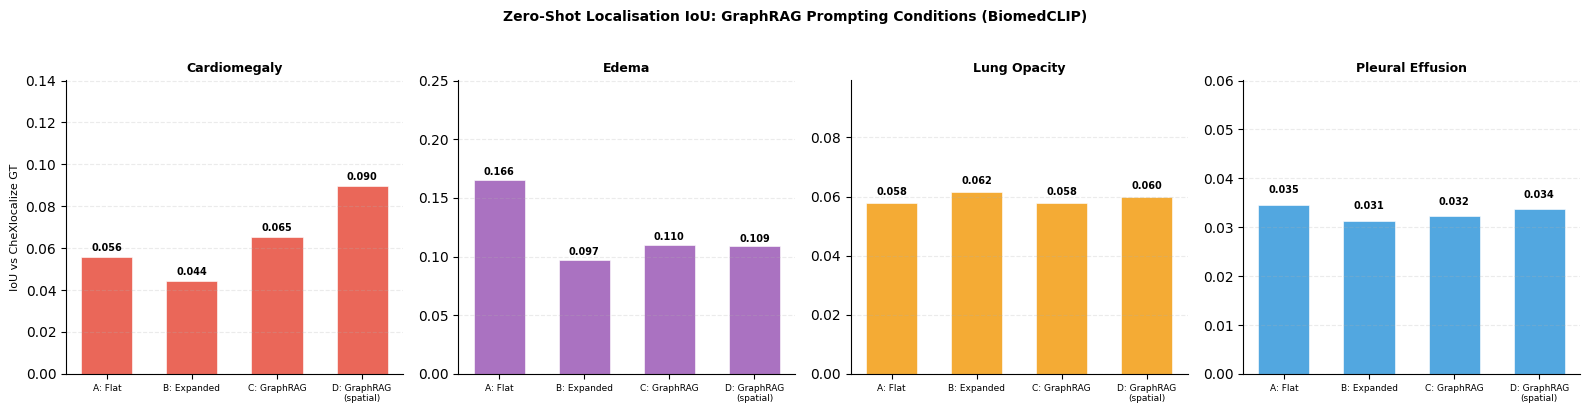

Figure 1 saved.


In [7]:
# 5a. Paper figure 1: IoU by condition — BiomedCLIP (clean version)
x = np.arange(len(CONDITIONS))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor('white')

for ax, label in zip(axes, PATHOLOGIES):
    ious  = [summary_bc[c][label]['iou'] for c in CONDITIONS]
    color = PATHOLOGY_COLORS[label]
    bars  = ax.bar(x, ious, color=color, alpha=0.85, width=0.6, edgecolor='white', linewidth=0.5)

    for bar, val in zip(bars, ious):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

    ax.set_ylim(0, max(ious) * 1.45 + 0.01)
    ax.set_title(label, fontsize=9, fontweight='bold', pad=6)
    ax.set_xticks(x)
    ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS], fontsize=6.5)
    ax.grid(alpha=0.25, axis='y', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax is axes[0]:
        ax.set_ylabel('IoU vs CheXlocalize GT', fontsize=8)

plt.suptitle('Zero-Shot Localisation IoU: GraphRAG Prompting Conditions (BiomedCLIP)',
             fontsize=10, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PAPER_DIR}/fig1_iou_biomedclip.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{PAPER_DIR}/fig1_iou_biomedclip.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

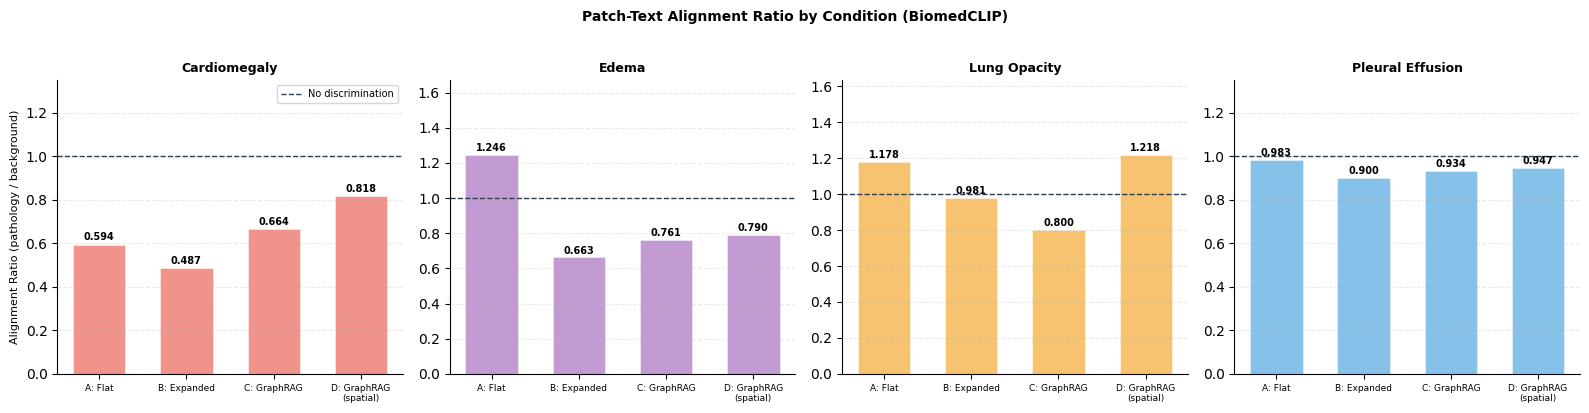

Figure 2 saved.


In [8]:
# 5b. Paper figure 2: alignment ratio — BiomedCLIP (clean version)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor('white')

for ax, label in zip(axes, PATHOLOGIES):
    ratios = [summary_bc[c][label]['alignment_ratio'] for c in CONDITIONS]
    color  = PATHOLOGY_COLORS[label]
    bars   = ax.bar(x, ratios, color=color, alpha=0.6, width=0.6, edgecolor='white', linewidth=0.5)
    ax.axhline(1.0, color='#2c3e50', linestyle='--', linewidth=1.0, label='No discrimination')

    for bar, val in zip(bars, ratios):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

    y_max = max(max(ratios), 1.0)
    ax.set_ylim(0, y_max * 1.3 + 0.05)
    ax.set_title(label, fontsize=9, fontweight='bold', pad=6)
    ax.set_xticks(x)
    ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS], fontsize=6.5)
    ax.grid(alpha=0.25, axis='y', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax is axes[0]:
        ax.set_ylabel('Alignment Ratio (pathology / background)', fontsize=8)
        ax.legend(fontsize=7)

plt.suptitle('Patch-Text Alignment Ratio by Condition (BiomedCLIP)',
             fontsize=10, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PAPER_DIR}/fig2_alignment_biomedclip.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{PAPER_DIR}/fig2_alignment_biomedclip.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

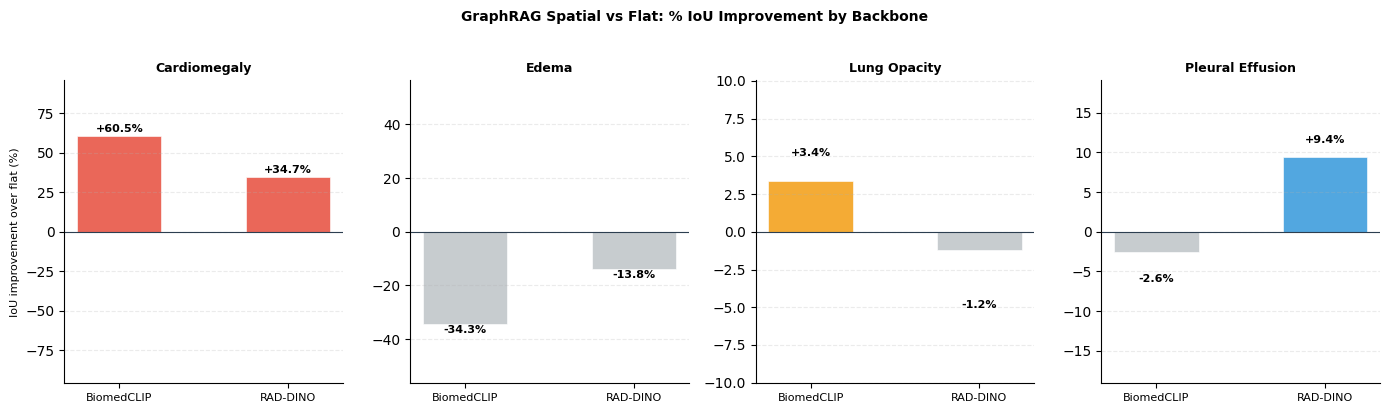

Figure 3 saved.


In [9]:
# 5c. Paper figure 3: cross-backbone IoU improvement (clean version)
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.patch.set_facecolor('white')

for ax, label in zip(axes, PATHOLOGIES):
    flat_bc    = summary_bc['flat'][label]['iou']
    spatial_bc = summary_bc['graphrag_spatial'][label]['iou']
    flat_rd    = summary_rd['flat'][label]['iou']
    spatial_rd = summary_rd['graphrag_spatial'][label]['iou']

    delta_bc = (spatial_bc - flat_bc) / (flat_bc + 1e-10) * 100
    delta_rd = (spatial_rd - flat_rd) / (flat_rd + 1e-10) * 100

    color    = PATHOLOGY_COLORS[label]
    x_labels = ['BiomedCLIP', 'RAD-DINO']
    deltas   = [delta_bc, delta_rd]
    bar_colors = [color if d >= 0 else '#bdc3c7' for d in deltas]

    bars = ax.bar(x_labels, deltas, color=bar_colors, alpha=0.85,
                  width=0.5, edgecolor='white', linewidth=0.5)
    ax.axhline(0, color='#2c3e50', linewidth=0.8)

    for bar, val in zip(bars, deltas):
        offset = 1.5 if val >= 0 else -4
        ax.text(bar.get_x() + bar.get_width()/2, val + offset,
                f'{val:+.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

    y_abs = max(abs(delta_bc), abs(delta_rd))
    ax.set_ylim(-y_abs * 1.5 - 5, y_abs * 1.5 + 5)
    ax.set_title(label, fontsize=9, fontweight='bold', pad=6)
    ax.grid(alpha=0.25, axis='y', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=8)
    if ax is axes[0]:
        ax.set_ylabel('IoU improvement over flat (%)', fontsize=8)

plt.suptitle('GraphRAG Spatial vs Flat: % IoU Improvement by Backbone',
             fontsize=10, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PAPER_DIR}/fig3_improvement_backbones.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{PAPER_DIR}/fig3_improvement_backbones.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

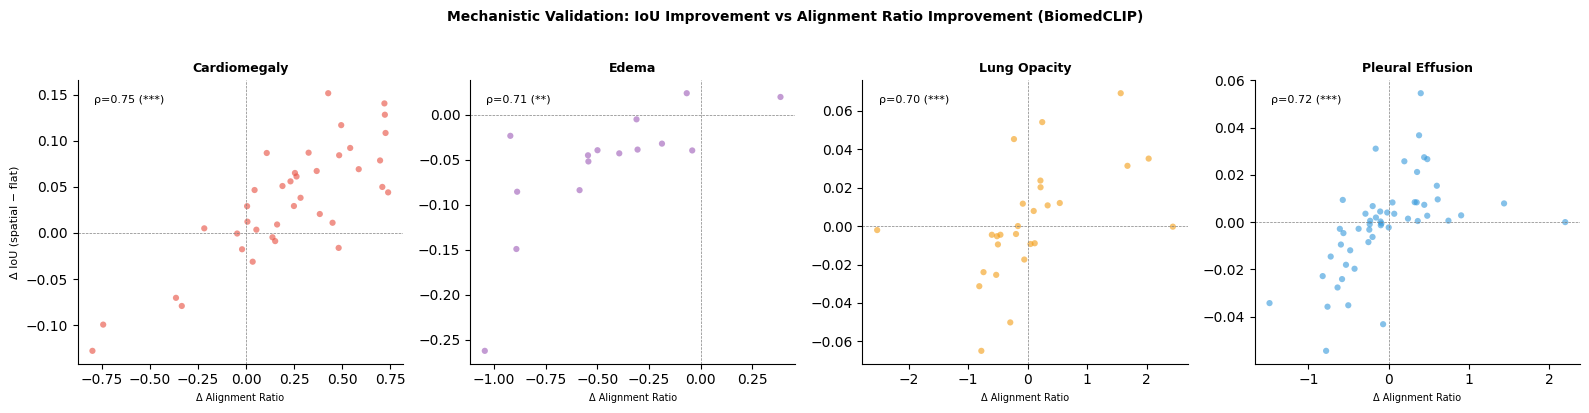

Figure 4 saved.


In [10]:
# 5d. Paper figure 4: correlation scatter — delta IoU vs delta alignment ratio (BiomedCLIP)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor('white')

flat_by_idx    = {r['idx']: r for r in results_bc['flat']}
spatial_by_idx = {r['idx']: r for r in results_bc['graphrag_spatial']}

for ax, label in zip(axes, PATHOLOGIES):
    delta_iou, delta_align = [], []
    for idx, flat_r in flat_by_idx.items():
        if flat_r['label'] != label:
            continue
        spatial_r = spatial_by_idx.get(idx)
        if spatial_r is None:
            continue
        if np.isnan(flat_r['alignment_ratio']) or np.isnan(spatial_r['alignment_ratio']):
            continue
        delta_iou.append(spatial_r['iou'] - flat_r['iou'])
        delta_align.append(spatial_r['alignment_ratio'] - flat_r['alignment_ratio'])

    if not delta_iou:
        continue

    color = PATHOLOGY_COLORS[label]
    ax.scatter(delta_align, delta_iou, c=color, alpha=0.6, s=20, edgecolors='none')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')

    if len(delta_iou) >= 5:
        rho, p_val = stats.spearmanr(delta_align, delta_iou)
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        ax.text(0.05, 0.95, f'ρ={rho:.2f} ({sig})',
                transform=ax.transAxes, fontsize=8,
                verticalalignment='top')

    ax.set_title(label, fontsize=9, fontweight='bold', pad=6)
    ax.set_xlabel('Δ Alignment Ratio', fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax is axes[0]:
        ax.set_ylabel('Δ IoU (spatial − flat)', fontsize=8)

plt.suptitle('Mechanistic Validation: IoU Improvement vs Alignment Ratio Improvement (BiomedCLIP)',
             fontsize=10, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PAPER_DIR}/fig4_correlation.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{PAPER_DIR}/fig4_correlation.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

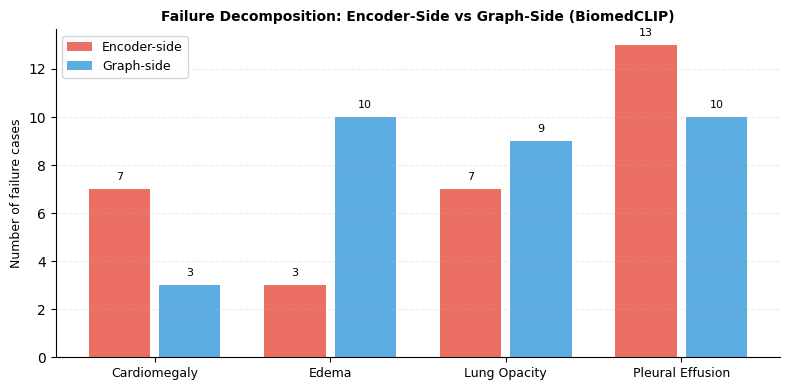

Figure 5 saved.


In [11]:
# 5e. Paper figure 5: failure decomposition bar chart
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('white')

x_pos    = np.arange(len(PATHOLOGIES))
encoder  = [failure_counts[label]['encoder'] for label in PATHOLOGIES]
graph    = [failure_counts[label]['graph']   for label in PATHOLOGIES]

bars_enc = ax.bar(x_pos - 0.2, encoder, 0.35, label='Encoder-side', color='#e74c3c', alpha=0.8)
bars_grp = ax.bar(x_pos + 0.2, graph,   0.35, label='Graph-side',   color='#3498db', alpha=0.8)

for bar in list(bars_enc) + list(bars_grp):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
            str(int(h)), ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_pos)
ax.set_xticklabels(PATHOLOGIES, fontsize=9)
ax.set_ylabel('Number of failure cases', fontsize=9)
ax.set_title('Failure Decomposition: Encoder-Side vs Graph-Side (BiomedCLIP)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.25, axis='y', linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PAPER_DIR}/fig5_failure_decomposition.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{PAPER_DIR}/fig5_failure_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

In [12]:
# final results summary for paper
print('=' * 70)
print('FINAL RESULTS SUMMARY')
print('=' * 70)

print('\nBiomedCLIP IoU (flat → graphrag_spatial):')
for label in PATHOLOGIES:
    flat    = summary_bc['flat'][label]['iou']
    spatial = summary_bc['graphrag_spatial'][label]['iou']
    delta   = (spatial - flat) / (flat + 1e-10) * 100
    mwu     = mwu_results.get('BiomedCLIP', {}).get(label, {})
    p_val   = mwu.get('p', float('nan'))
    sig     = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    print(f'  {label:<20} {flat:.4f} → {spatial:.4f}  ({delta:+.1f}%)  p={p_val:.4f} {sig}')

print('\nRAD-DINO IoU (flat → graphrag_spatial):')
for label in PATHOLOGIES:
    flat    = summary_rd['flat'][label]['iou']
    spatial = summary_rd['graphrag_spatial'][label]['iou']
    delta   = (spatial - flat) / (flat + 1e-10) * 100
    mwu     = mwu_results.get('RAD-DINO', {}).get(label, {})
    p_val   = mwu.get('p', float('nan'))
    sig     = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    print(f'  {label:<20} {flat:.4f} → {spatial:.4f}  ({delta:+.1f}%)  p={p_val:.4f} {sig}')

print('\nSpearman correlation (delta IoU vs delta alignment ratio, BiomedCLIP):')
for label in PATHOLOGIES:
    c = corr_results.get('BiomedCLIP', {}).get(label, {})
    if c:
        sig = '***' if c['p'] < 0.001 else '**' if c['p'] < 0.01 else '*' if c['p'] < 0.05 else 'ns'
        print(f'  {label:<20} rho={c["rho"]:+.3f}  p={c["p"]:.4f}  {sig}')

print('\nAll paper figures saved to:', PAPER_DIR)

FINAL RESULTS SUMMARY

BiomedCLIP IoU (flat → graphrag_spatial):
  Cardiomegaly         0.0559 → 0.0897  (+60.5%)  p=0.0031 **
  Edema                0.1656 → 0.1088  (-34.3%)  p=0.0465 *
  Lung Opacity         0.0579 → 0.0598  (+3.4%)  p=1.0000 ns
  Pleural Effusion     0.0345 → 0.0336  (-2.6%)  p=0.6072 ns

RAD-DINO IoU (flat → graphrag_spatial):
  Cardiomegaly         0.1150 → 0.1549  (+34.7%)  p=0.0038 **
  Edema                0.1259 → 0.1085  (-13.8%)  p=0.5069 ns
  Lung Opacity         0.0578 → 0.0571  (-1.2%)  p=0.7806 ns
  Pleural Effusion     0.0443 → 0.0484  (+9.4%)  p=0.6660 ns

Spearman correlation (delta IoU vs delta alignment ratio, BiomedCLIP):
  Cardiomegaly         rho=+0.746  p=0.0000  ***
  Edema                rho=+0.707  p=0.0032  **
  Lung Opacity         rho=+0.702  p=0.0000  ***
  Pleural Effusion     rho=+0.717  p=0.0000  ***

All paper figures saved to: /content/drive/MyDrive/medvit-graphrag/figures/paper
